## **IMPORT REQUIRED LIBRARIES**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA

sns.set(style='whitegrid')
%matplotlib inline

## **DATASET LOADING AND PREPARATION**

In [2]:
# Load data
data = pd.read_excel('credit_clusters.xlsx')

## **MODEL 01: ORIGINAL DATASET**

In [3]:
# Split dataset
y = data['default_payment_next_month']
X = data.drop(columns=['default_payment_next_month'])

categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6','Cluster']
X[categorical_cols] = X[categorical_cols].astype(str)
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# One-hot encoding
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(X[categorical_cols])
cat_feature_names = encoder.get_feature_names_out(categorical_cols)

X_num = X[numerical_cols].values
X_final = np.hstack([X_cat, X_num])
X_df_encoded = pd.DataFrame(X_final, columns=list(cat_feature_names) + numerical_cols)
X_df_encoded.head()

,SEX_2,EDUCATION_1,EDUCATION_2,EDUCATION_3,EDUCATION_4,EDUCATION_5,EDUCATION_6,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0


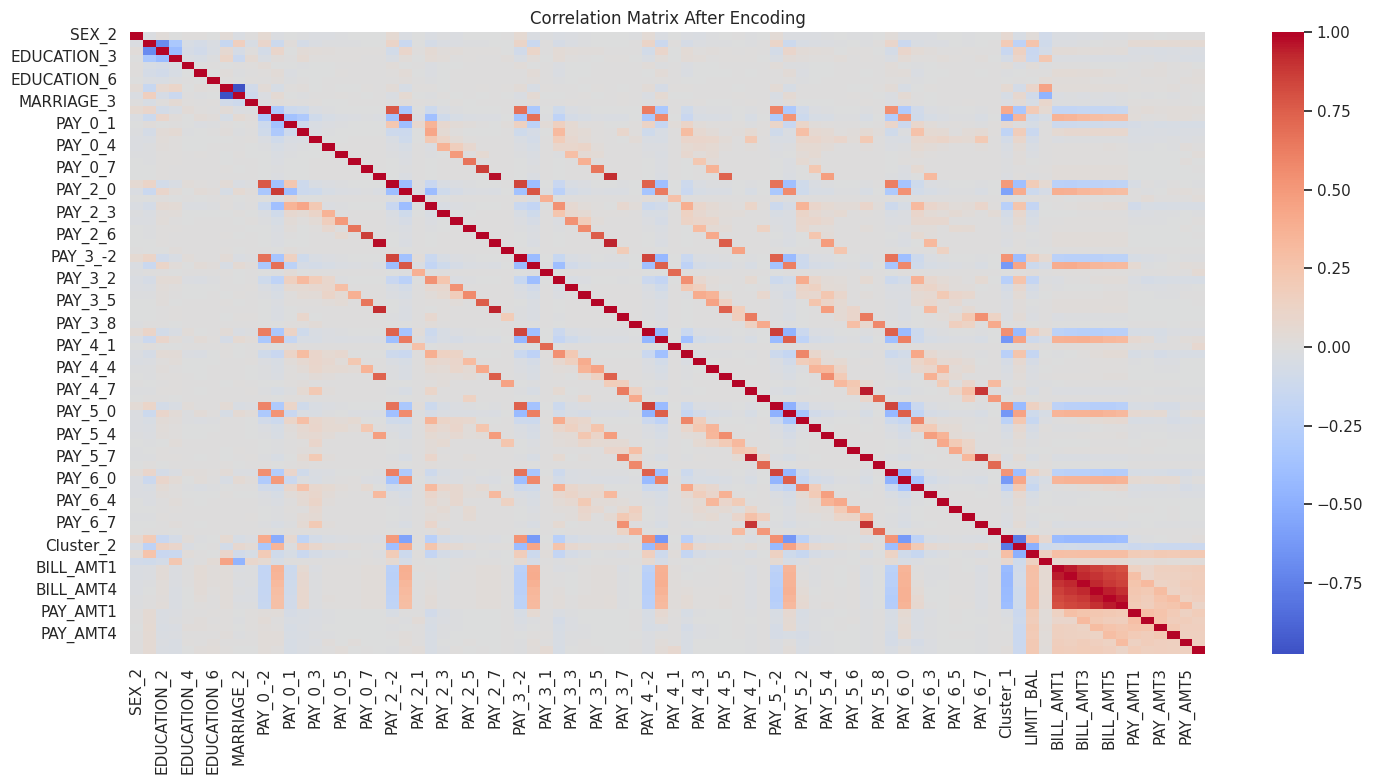

In [4]:
# Correlation Matrix for Multicollinearity
plt.figure(figsize=(15, 8))
sns.heatmap(X_df_encoded.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Matrix After Encoding")
plt.tight_layout()
plt.show()

default_payment_next_month
0    23364
1     6636
Name: count, dtype: int64


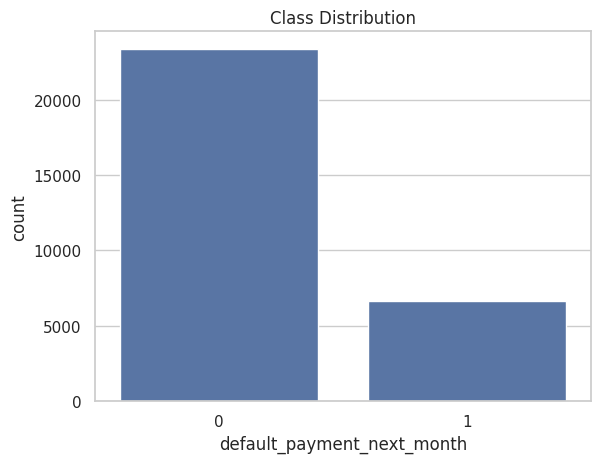

In [5]:
# Dataset Balance check

print(y.value_counts())
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()

In [13]:
# Split, train and evaluate
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)


print("=== Model without PCA ===")
print(classification_report(y_test, y_pred))

=== Model without PCA ===
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4687
           1       0.48      0.57      0.52      1313

    accuracy                           0.77      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.77      0.78      6000



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Create dataframe with resultados
feature_names = encoder.get_feature_names_out(categorical_cols).tolist() + list(X.drop(columns=categorical_cols).columns)
results = pd.DataFrame(X_test, columns=feature_names)
results['y_true'] = y_test.values
results['y_pred'] = y_pred
results['y_proba'] = y_proba
results.to_csv("results.csv", index=False)

# Export coefficients for feature importance chart
coefficients = pd.DataFrame({
    'Feature': encoder.get_feature_names_out(categorical_cols).tolist() + list(X.drop(columns=categorical_cols).columns),
    'Coefficient': model.coef_[0]
})
coefficients.to_csv("logistic_coefficients.csv", index=False)

# ROC curve calculation
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_data = pd.DataFrame({
    'FPR': fpr,
    'TPR': tpr,
    'Threshold': thresholds
})

# Exportar a CSV
roc_data.to_csv("roc_curve.csv", index=False)

## **MODEL 02: DATASET WITH PCA**

In [14]:
# PCA on BILL_AMT ---
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
X_bill = data[bill_cols]
scaler = StandardScaler()
X_bill_scaled = scaler.fit_transform(X_bill)

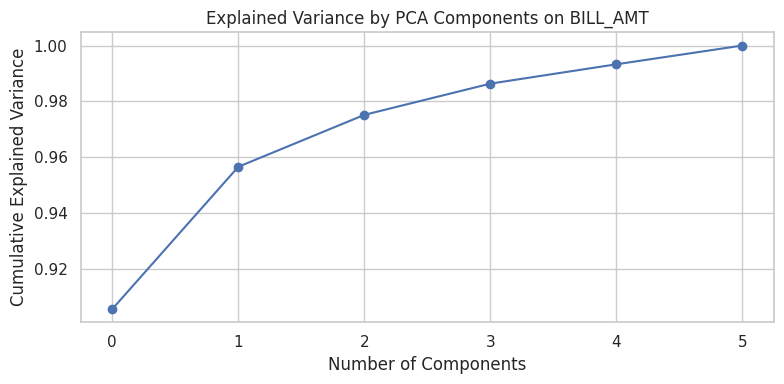

Optimal number of components for BILL_AMT: 2


In [15]:
# PCA to determine optimal componen number
pca_full = PCA()
pca_full.fit(X_bill_scaled)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components on BILL_AMT")
plt.grid(True)
plt.tight_layout()
plt.show()

# Select component that expliain at least 95% of variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cum_var >= 0.95) + 1
print(f"Optimal number of components for BILL_AMT: {n_components}")

In [9]:
# Apply PCA with optimal number
pca = PCA(n_components=n_components)
X_bill_pca = pca.fit_transform(X_bill_scaled)
df_pca = pd.DataFrame(X_bill_pca, columns=[f'PCA_BILL_{i+1}' for i in range(n_components)])

# Replace BILL_AMT with PCA components
df_reduced = data.drop(columns=bill_cols).copy()
df_reduced = pd.concat([df_reduced, df_pca], axis=1)

# New variables
X_reduced = df_reduced.drop(columns=['default_payment_next_month'])
y_reduced = df_reduced['default_payment_next_month']

# Refresh lists
categorical_cols_r = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'Cluster']
numerical_cols_r = [col for col in X_reduced.columns if col not in categorical_cols_r]

# One-hot encoding
encoder_r = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_cat_r = encoder_r.fit_transform(X_reduced[categorical_cols_r])
cat_feature_names_r = encoder_r.get_feature_names_out(categorical_cols_r)

X_num_r = X_reduced[numerical_cols_r].values
X_final_r = np.hstack([X_cat_r, X_num_r])
X_df_encoded_r = pd.DataFrame(X_final_r, columns=list(cat_feature_names_r) + numerical_cols_r)

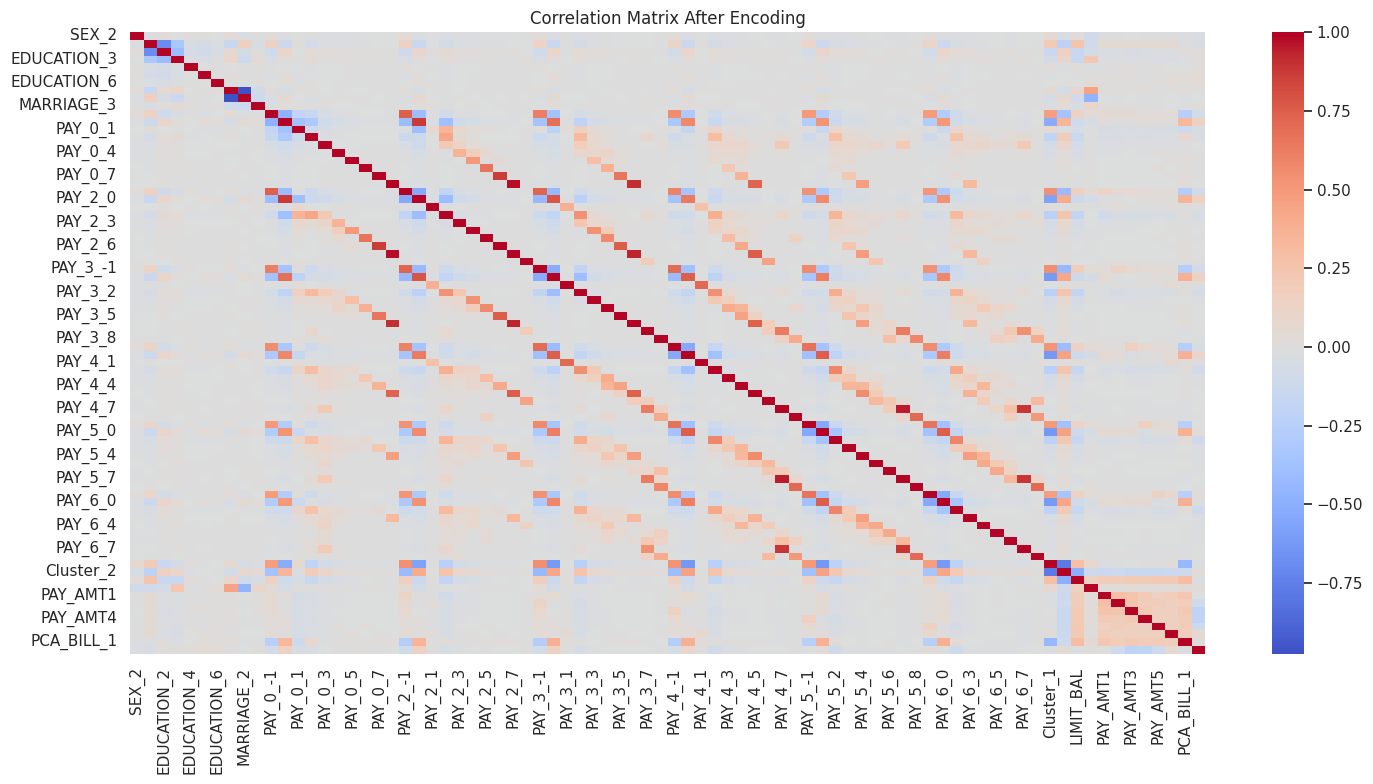

In [10]:
# Correlation matrix
plt.figure(figsize=(15, 8))
sns.heatmap(X_df_encoded_r.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Matrix After Encoding")
plt.tight_layout()
plt.show()

In [16]:
# Split and train data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_final_r, y_reduced, test_size=0.2, random_state=42)

model_r = LogisticRegression(class_weight='balanced', max_iter=1000)
model_r.fit(X_train_r, y_train_r)

y_pred_r = model_r.predict(X_test_r)
y_proba_r = model_r.predict_proba(X_test_r)[:, 1]
fpr_r, tpr_r, _ = roc_curve(y_test_r, y_proba_r)
roc_auc_r = auc(fpr_r, tpr_r)

print("=== Model with PCA ===")
print(classification_report(y_test_r, y_pred_r))

=== Model with PCA ===
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      4687
           1       0.47      0.58      0.52      1313

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.79      0.76      0.77      6000



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Create dataframe with resultados
feature_names_r = encoder.get_feature_names_out(categorical_cols_r).tolist() + list(X_reduced.drop(columns=categorical_cols_r).columns)
results_r = pd.DataFrame(X_test_r, columns=feature_names_r)
results_r['y_true'] = y_test_r.values
results_r['y_pred'] = y_pred_r
results_r['y_proba'] = y_proba_r
results_r.to_csv("results_r.csv", index=False)

# Export coefficients for feature importance chart
coefficients = pd.DataFrame({
    'Feature': encoder.get_feature_names_out(categorical_cols).tolist() + list(X.drop(columns=categorical_cols).columns),
    'Coefficient': model.coef_[0]
})
coefficients.to_csv("logistic_coefficients_r.csv", index=False)

# ROC curve calculation
fpr_r, tpr_r, thresholds = roc_curve(y_test_r, y_proba_r)
roc_data_r = pd.DataFrame({
    'FPR': fpr_r,
    'TPR': tpr_r,
    'Threshold': thresholds
})

# Export CSV
roc_data_r.to_csv("roc_curve_r.csv", index=False)

## **MODEL COMPARISON**

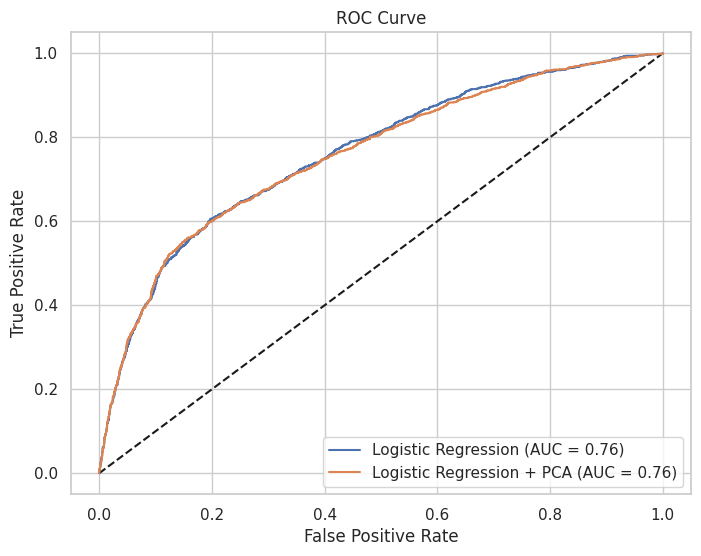

In [17]:
# ROC CURVE

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot(fpr_r, tpr_r, label=f'Logistic Regression + PCA (AUC = {roc_auc_r:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
